<a href="https://colab.research.google.com/github/rahiakela/transformers-research-and-practice/blob/main/build-reasoning-model-from-scratch/04-inference-time-scaling/01_inference_time_scaling_via_self_refinement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chapter 5: Inference-Time Scaling Via Self-Refinement



Packages that are being used in this notebook:

In [1]:
!git clone --depth 1 https://github.com/rasbt/reasoning-from-scratch.git

Cloning into 'reasoning-from-scratch'...
remote: Enumerating objects: 258, done.
remote: Counting objects: 100% (258/258), done.
remote: Compressing objects: 100% (231/231), done.
remote: Total 258 (delta 45), reused 126 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (258/258), 1.43 MiB | 7.95 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [2]:
!mkdir -p rm_from_scratch
!cp -r reasoning-from-scratch/reasoning_from_scratch/* rm_from_scratch

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F01_raschka.webp" width=600>

Self-consistency  cover another popular and useful inference-scaling technique,
self-refinement.

Instead of generating and choosing from multiple answers,
self-refinement focuses on iteratively refining a single answer to correct potential mistakes.

## 5.1 Scoring and iteratively improving model responses

We’ve covered two inference-scaling techniques so far:
* chain-of-thought prompting and
* self-consistency.


Chain-of-thought prompting modifies the
prompt, such as by adding the phrase "Explain step by step.", which can trigger a
base model to write longer explanations that can in turn improve answer accuracy. This
method is particularly useful for base models that don’t naturally provide reasoning-like
explanations.

Self-consistency lets the model produce several
answers in parallel. We then choose the final answer by selecting the most frequent of
these candidates.

Now, we’ll implement a more versatile technique, self-refinement, in which
the LLM learns to improve its own answers iteratively.

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F02_raschka.webp" width=600>

Before we do so, though, we’ll first implement scoring functions to compare and rank different answers.

After loading the pretrained LLM, we’ll
implement a simple rule-based scoring function to illustrate the concept of scoring (step
2). Then we’ll go over the concepts of token probabilities (step 3) and token log probabilities (step 4), which we’ll need to implement the log-probability scoring (logprob scoring)
method (step 5) for our self-refinement loop (step 6).

We will primarily use the logprob scoring function (step 5 in figure 5.3) to track
progress within the self-refinement loop. These scoring functions can also be used to
break ties in self-consistency or to select the best response instead of relying on a majority
vote.

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F03_raschka.webp" width=600>

&nbsp;
## 5.2 Loading a pre-trained model

- Model loading code similar to chapter 2-4

- Note that we hardcode the `"cpu"` device below to make the results as similar as possible across different machines and operating systems
- I recommend running the chapter code here as is before deleting `device = torch.device("cpu")` below
- Even though we hardcode the `"cpu"` device, since the chapter involves the multiplication of many very small numbers, the results may differ on your computer (especially in section 5.4 and onward)

In [3]:
import torch

from rm_from_scratch.ch02 import get_device
from rm_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()
device = torch.device("cpu")  # optionally delete to allow running on GPU

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using CPU
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


- Let's try the model on a prompt from the MATH-500 dataset, which we worked with in the previous chapter:

In [4]:
from rm_from_scratch.ch03 import render_prompt
from rm_from_scratch.ch04 import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache
)

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
prompt_cot = prompt + "\n\nExplain step by step."

torch.manual_seed(0)
response_1 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9
)

 ### Step 1: Understand the problem

The problem states that half the value of \(3x - 9\) is equal to \(x + 37\). We need to find the value of \(x\).

### Step 2: Translate the problem into an equation

Let's translate the given statement into an equation. Half of \(3x - 9\) is equal to \(x + 37\).

\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 3: Solve the equation

We will solve the equation step by step to find the value of \(x\).

\[
\frac{1}{2}(3x - 9) = x + 37
\]

First, distribute the \(\frac{1}{2}\) on the left side:

\[
\frac{1}{2} \cdot 3x - \frac{1}{2} \cdot 9 = x + 37
\]

Simplify the left side:

\[
\frac{3}{2}x - \frac{9}{2} = x + 37
\]

Next, we want to get all terms involving \(x\) on one side of the equation. Subtract \(x\) from both sides:

\[
\frac{3}{2}x - x - \frac{9}{2} = 37
\]

Combine like terms on the left side:

\[
\frac{3}{2}x - \frac{2}{2}x - \frac{9}{2} = 37
\]

Simplify:

\[
\frac{1}{2}x - \frac{9}{2} = 37
\]

Now, add \(\frac{9}{2}\) to both sides to isolat

Because we are using temperature scaling and top-p sampling, changing the random
seed produces a different response:

In [5]:
torch.manual_seed(3)
response_2 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

 We start with the equation:

\[
\frac{1}{2} \times (3x - 9) = x + 37
\]

Step 1: Multiply both sides of the equation by 2 to eliminate the fraction:

\[
2 \times \frac{1}{2} \times (3x - 9) = 2 \times (x + 37)
\]

Simplifying both sides:

\[
3x - 9 = 2x + 74
\]

Step 2: Subtract \(2x\) from both sides to get all the \(x\) terms on one side:

\[
3x - 2x - 9 = 74
\]

Simplifying:

\[
x - 9 = 74
\]

Step 3: Add 9 to both sides to isolate \(x\):

\[
x - 9 + 9 = 74 + 9
\]

Simplifying:

\[
x = 83
\]

Final Answer:

\[
\boxed{83}
\]

The second response
is much shorter, which we can confirm by printing the number of characters or tokens
in each response:

In [6]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("\nResponse 2 characters:", len(response_2))
print("Response 2 tokens:", len(tokenizer.encode(response_2)))

Response 1 characters: 1772
Response 1 tokens: 699

Response 2 characters: 533
Response 2 tokens: 231


- By the way, the correct answer is 83

A shorter response is not necessarily better. If two responses reach the same correct
answer, judging which is better is not straightforward. It often depends on human preferences
regarding clarity, usefulness, and the partial correctness of the intermediate
steps.

If the qualitative value of two responses is comparable, one thing is certain: shorter
responses are cheaper because they require fewer tokens to be generated, and these
responses are therefore preferred.

## 5.3 Scoring LLM responses with a rule-based score

Let's develop a simple rule-based scoring function to compare them.

The rule-based scoring function will assign a score to each of two LLM responses, which will allow us to rank them and select the better one.

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F04_raschka.webp" width=600>

There are several ways to implement a scoring function (scorer) for evaluating
responses. The scorer can be heuristic, meaning a simple rulebased
method. It can also be another LLM that rates the answers, often referred to as
LLM-as-a-judge. It can also rely on internal probability scores or likelihoods.


- Can be used as a tie breaker for self-consistency
- Or can be used to score and rank all self-consistency responses (this is known as Best-of-N inference-scaling)

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F05_raschka.webp" width=600>

Let's begin with a heuristic, a rule-based scorer that will make the later probability-based scorers
easier to compare and reason about.

In [7]:
from rm_from_scratch.ch03 import extract_final_candidate
import math

def heuristic_score(
    answer,
    prompt=None,  # Placeholder that is ignored
    brevity_bonus=500.0,
    boxed_bonus=2.0,
    extract_bonus=1.0,
    fulltext_bonus=0.0,
):
    score = 0.0

    # Reward answers that have a final boxed value
    cand = extract_final_candidate(answer, fallback="none")
    if cand:
        score += boxed_bonus

    # Give weaker rewards if answer doesn't have a boxed value
    else:
        cand = extract_final_candidate(answer, fallback="number_only")
        if cand:
            score += extract_bonus
        else:
            cand = extract_final_candidate(
                answer, fallback="number_then_full"
            )
            if cand:
                score += fulltext_bonus

    # Add a brevity reward that decays with text length
    score += 1.5 * math.exp(-len(answer) / brevity_bonus)
    return score

- Note that the code measures the number of characters, instead of tokens, for simplicity, so we don't have to pass a tokenizer here, but this can easily be changed

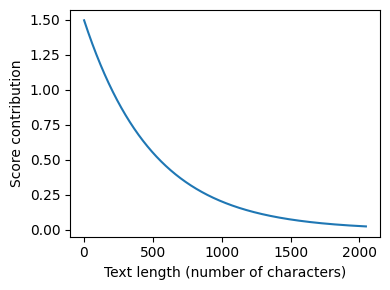

In [8]:
import matplotlib.pyplot as plt

def plot_brevity_curve(brevity_bonus, max_len=2048):
    lengths = torch.arange(1, max_len)
    scores = 1.5 * torch.exp(-lengths / brevity_bonus)

    plt.figure(figsize=(4, 3))
    plt.plot(lengths, scores)
    plt.xlabel("Text length (number of characters)")
    plt.ylabel("Score contribution")
    plt.tight_layout()
    #plt.savefig("brevity_curve.pdf")
    plt.show()

plot_brevity_curve(500)

In [9]:
print(round(heuristic_score(response_1), 3))

2.043


In [10]:
print(round(heuristic_score(response_2), 3))

2.517


## 5.4 Understanding token probability scores

If the tokens in a proposed answer consistently receive high
probability, this suggests that the answer is more compatible with the model’s own
internal preferences. Conversely, if the model assigns very low probability to many
of the answer tokens, that’s a sign that the model itself does not strongly support
that answer.

Let's start by computing the token probability scores for a proposed
answer and use them to estimate how likely the model considers that answer to be

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F07_raschka.webp" width=600>

For example, consider two candidate answers we want to score:
* "The capital of Germany is Berlin"
* "The capital of Germany is Bridge"

Our goal is to quantify how confident the model is in each answer.



<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F08_raschka.webp" width=600>

The input text "The capital of Germany is" is fed to the model, and the
next token with the highest score ("Berlin") is selected. Instead of selecting a token,
here we’ll compare the scores assigned to two candidate next tokens, "Berlin" and
"Bridge".

Rather than working with the raw logits, we convert them
to probabilities. Probabilities are easier to interpret, they’re comparable across
inputs, and they form the basis for the logprob scoring method.

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F09_raschka.webp" width=600>

As we know, applying torch.softmax converts logits into probability
values. The resulting probability distribution and the token probabilities are computed using torch.softmax
as part of the multinomial sampling procedure.

The difference here is that we do not sample from the distribution. Instead, we simply look up the probability assigned to specific tokens.

Here, only the bar for "Berlin" is visible, with a probability of 0.1695. The
probabilities for other tokens in the plotted range are near zero. This indicates that the
model assigns higher confidence to "Berlin" than to "Bridge" as the next token, given
the input text "The capital of Germany is".

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F10_raschka.webp" width=600>

In practice, we usually want to compare complete answers rather than individual tokens.

During ordinary text generation, the model does this one step at a time as it goes
along, selecting the next token.

Here, we use the same mechanism in a different way:
instead of sampling new tokens, we take a completed candidate answer and score each
of its tokens one by one under the model. We then multiply these probabilities to obtain
the probability of the full sequence, also called the **joint probability**.

Ideally, the probability assigned to the sequence "The capital of Germany is Berlin"
should be much higher than that of the nonsensical answer "The capital of Germany
is Bridge". Because the joint probability is obtained by multiplying many small values,
the resulting probabilities for both sequences are close to zero.

The two answers in this example are nearly identical, differing only in the final token
("Berlin" versus "Bridge").

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F11_raschka.webp" width=600>

In [ ]:
@torch.inference_mode()
def calc_next_token_probas(model, tokenizer, prompt, device, show=True):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    # Get logits and probabilities similar to text generation functions
    logits = model(token_ids.unsqueeze(0)).squeeze(0)
    all_probas = torch.softmax(logits, dim=-1)

    # Positions we score (here: all)
    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)

    # Since we have the text, we know the true next tokens
    next_ids = token_ids[1:]

    # Get probabilities for each next token
    next_token_probas = all_probas[t_idx, next_ids]

    # Likelihood of the sequence is the product of the probability scores
    prod_next_token_probas = torch.prod(next_token_probas)

    if show:
        print("Next-token probabilities:", next_token_probas)
        print("Joint probability:", prod_next_token_probas)

    else:
        return next_token_probas, prod_next_token_probas

\begin{align}
P(x_1, x_2, \dots, x_T \mid W)
&= \prod_{t=1}^{T} P(x_t \mid x_{1:t-1}, W) \\
&= P(x_1 \mid W) \, \cdot \,
   P(x_2 \mid x_1, W) \, \cdot \,
   P(x_3 \mid x_{1:2}, W) \,
   \cdots \,
   P(x_T \mid x_{1:T-1}, W)
\end{align}

- Where $W$ are the model parameters (the learned weights), $x$ is the sequence of tokens, and $T$ is the number of tokens
- The numbers below, because they are so close to zero, will slightly differ on CPU, MPS, and CUDA devices

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F12_raschka.webp" width=600>

In [ ]:
torch.set_printoptions(precision=4, sci_mode=True)

In [ ]:
calc_next_token_probas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Berlin"
    )

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 1.6895e-01],
       dtype=torch.bfloat16)
Joint probability: tensor(5.9372e-08, dtype=torch.bfloat16)


In [ ]:
calc_next_token_probas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Bridge"
    )

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 2.9802e-07],
       dtype=torch.bfloat16)
Joint probability: tensor(1.0481e-13, dtype=torch.bfloat16)


In [ ]:
calc_next_token_probas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Hamburg"
    )

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 2.9297e-02],
       dtype=torch.bfloat16)
Joint probability: tensor(1.0303e-08, dtype=torch.bfloat16)


&nbsp;
## 5.5 From token probability scores to log-probabilities

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F13_raschka.webp" width=600>

- We introduce one more concept, log-probabilities (short: logprobs), they are similar to the probabilities we compute via the softmax function in the previous section, but we simply take the log

In [ ]:
torch.set_printoptions(precision=4, sci_mode=False)

In [ ]:
logits = torch.linspace(-2, 2, steps=7)
probas = torch.softmax(logits, dim=-1)
print(probas)

tensor([0.0090, 0.0175, 0.0341, 0.0665, 0.1295, 0.2522, 0.4912])


In [ ]:
print(torch.log(probas))

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


In [ ]:
log_probas = torch.log_softmax(logits, dim=-1)
print(log_probas)

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


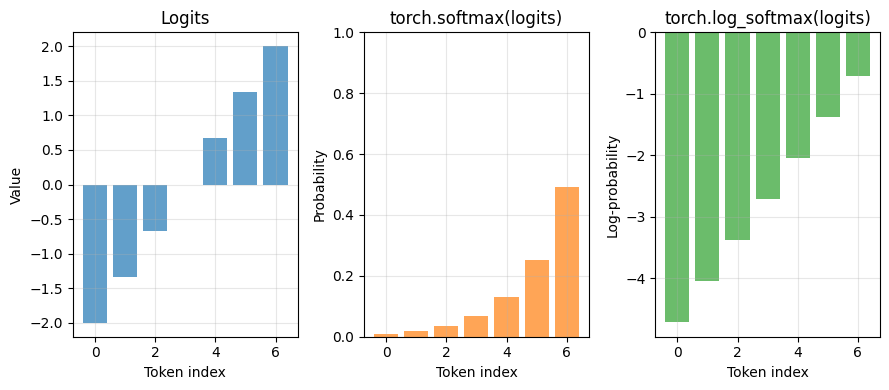

In [ ]:
plt.figure(figsize=(9, 4))

# Logits
plt.subplot(1, 3, 1)
plt.bar(range(len(logits)), logits, color="C0", alpha=0.7)
plt.title("Logits")
plt.xlabel("Token index")
plt.ylabel("Value")
plt.grid(alpha=0.3)

# Softmax
plt.subplot(1, 3, 2)
plt.bar(range(len(probas)), probas, color="C1", alpha=0.7)
plt.title("torch.softmax(logits)")
plt.xlabel("Token index")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

# Log-softmax
plt.subplot(1, 3, 3)
plt.bar(range(len(log_probas)), log_probas, color="C2", alpha=0.7)
plt.title("torch.log_softmax(logits)")
plt.xlabel("Token index")
plt.ylabel("Log-probability")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("logits_softmax_log_softmax.pdf")
plt.show()

- The logprobs are in a more reasonable range for numerically stable computing

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F15_raschka.webp" width=600>

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F16_raschka.webp" width=600>

\begin{align}
\log P(x_1, x_2, \dots, x_T \mid W)
&= \log \prod_{t=1}^{T} P(x_t \mid x_{1:t-1}, W) \\
&= \sum_{t=1}^{T} \log P(x_t \mid x_{1:t-1}, W) \\
&= \log P(x_1 \mid W)
   + \log P(x_2 \mid x_1, W)
   + \log P(x_3 \mid x_{1:2}, W)
   + \cdots
   + \log P(x_T \mid x_{1:T-1}, W).
\end{align}

In [ ]:
@torch.inference_mode()
def calc_next_token_logprobas(model, tokenizer, prompt, device, show=True):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    logits = model(token_ids.unsqueeze(0)).squeeze(0)
    # We now use log_softmax
    all_logprobas = torch.log_softmax(logits, dim=-1)

    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)
    next_ids = token_ids[1:]
    next_token_logprobas = all_logprobas[t_idx, next_ids]

    # We replace the product with a sum
    sum_next_token_logprobas = torch.sum(next_token_logprobas)

    if show:
        print("Next-token log-probabilities:", next_token_logprobas)
        print("Joint log-probability:", sum_next_token_logprobas)
    else:
        return next_token_logprobas, sum_next_token_logprobas

In [ ]:
calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Berlin"
    )

Next-token log-probabilities: tensor([-9.6875, -0.7695, -4.0938, -0.3008, -1.7812], dtype=torch.bfloat16)
Joint log-probability: tensor(-16.6250, dtype=torch.bfloat16)


In [ ]:
calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Bridge"
    )

Next-token log-probabilities: tensor([ -9.6875,  -0.7695,  -4.0938,  -0.3008, -15.0000],
       dtype=torch.bfloat16)
Joint log-probability: tensor(-29.8750, dtype=torch.bfloat16)


In [ ]:
calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Hamburg"
    )

Next-token log-probabilities: tensor([-9.6875, -0.7695, -4.0938, -0.3008, -3.5312], dtype=torch.bfloat16)
Joint log-probability: tensor(-18.3750, dtype=torch.bfloat16)


&nbsp;
## 5.6 Scoring model confidence with log-probabilities

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F17_raschka.webp" width=600>

- We turn the logprob scoring into a scoring function that we can use, similar to the heuristic score
- We make a few tweaks compared to the previous section: (1) we only score the answer, not the prompt; (2) we average over the token scores

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F18_raschka.webp" width=600>

In [ ]:
example_prompt = "What is the capital of Germany?"
example_answer = " The capital of Germany is Berlin."

next_token_logprobas, sum_next_token_logprobas = calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt=example_prompt+example_answer,
        show=False
    )

print("Next-token logprobas:", next_token_logprobas)
print("Joint log-probability:", sum_next_token_logprobas)

Next-token logprobas: tensor([-0.4512, -0.3418, -8.3125, -0.3906, -3.8125, -3.0469, -1.1719,  0.0000,
        -0.0155,  0.0000, -0.0078, -0.0752, -0.1582], dtype=torch.bfloat16)
Joint log-probability: tensor(-17.7500, dtype=torch.bfloat16)


In [ ]:
print(len(tokenizer.encode(example_answer)))

7


In [ ]:
last_7 = next_token_logprobas[-7:]
print(last_7)

tensor([-1.1719,  0.0000, -0.0155,  0.0000, -0.0078, -0.0752, -0.1582],
       dtype=torch.bfloat16)


In [ ]:
print(torch.mean(last_7))

tensor(-0.2041, dtype=torch.bfloat16)


In [ ]:
@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):

    # Encode prompt and answer tokens separately to get the prompt length later
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)

    # Same as in calc_next_token_logprobas before
    logits = model(full_ids.unsqueeze(0)).squeeze(0)
    logprobs = torch.log_softmax(logits, dim=-1)

    # Index range for positions corresponding to answer tokens
    start = len(prompt_ids) - 1
    end = full_ids.shape[0] - 1

    # Same as before, except for using start and end
    t_idx = torch.arange(start, end, device=device)
    next_tokens = full_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]

    # Average over the answer token scores
    return torch.mean(next_token_logps)

In [ ]:
score_1 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Berlin.",
    device=device
)
print(score_1)

tensor(-0.2041, dtype=torch.bfloat16)


In [ ]:
score_2 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Bridge.",
    device=device
)
print(score_2)

tensor(-3.8906, dtype=torch.bfloat16)


In [ ]:
avg_logprob_answer(
    model, tokenizer,
    prompt=prompt_cot,
    answer=response_1,
    device=device
)

tensor(-0.0898, dtype=torch.bfloat16)

In [ ]:
avg_logprob_answer(
    model, tokenizer,
    prompt=prompt_cot,
    answer=response_2,
    device=device
)

tensor(-0.1094, dtype=torch.bfloat16)

&nbsp;
## 5.7 Self-refinement through iterative feedback

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F19_raschka.webp" width=600>

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F20_raschka.webp" width=600>

In [ ]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

torch.manual_seed(123)
initial_response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 \boxed{18}

In [ ]:
def make_critique_prompt(raw_prompt, draft):
    return (
        "You are a meticulous reviewer. Identify logical errors, missing "
        "steps, or arithmetic mistakes. If the answer seems correct, "
        "say so briefly. Then propose a concise plan to fix issues.\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Draft answer:\n{draft}\n\n"
        "Write a short critique and bullet-point fix plan "
        "(under ~120 words).\n"
        "Critique:"
    )


critique_prompt = make_critique_prompt(raw_prompt, initial_response)
torch.manual_seed(123)
critique = generate_text_stream_concat_flex(
    model, tokenizer, critique_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 The question seems to have a logical error in its setup. The statement "Half the value of $3x-9$ is $x+37$" is incorrect because half of $3x-9$ should be $(3x-9)/2$, not $3x-9$. The equation should be $\frac{1}{2}(3x-9) = x + 37$.

Fix Plan:
1. Correct the equation to $\frac{1}{2}(3x-9) = x + 37$.
2. Multiply both sides by 2 to eliminate the fraction: $3x - 9 = 2(x + 37)$.
3. Distribute the 2 on the right side: $3x - 9 = 2x + 74$.
4. Subtract $2x$ from both sides: $x - 9 = 74$.
5. Add 9 to both sides: $x = 83$.

In [ ]:
def make_refine_prompt(raw_prompt, draft, critique):
    return (
        "Revise the answer using the critique. Keep it concise and "
        "end with a final boxed result: \\boxed{ANSWER}\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Previous answer:\n{draft}\n\n"
        f"Critique:\n{critique}\n\n"
        "Revised answer:"
    )

refine_prompt = make_refine_prompt(raw_prompt, initial_response, critique)
torch.manual_seed(123)
revised_answer = generate_text_stream_concat_flex(
    model, tokenizer, refine_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 \boxed{83}

Final result: The value of $x$ is \boxed{83}.

&nbsp;
## 5.8 Coding the self-refinement loop

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F21_raschka.webp" width=600>

In [ ]:
def self_refinement_loop(
    model,
    tokenizer,
    raw_prompt,
    device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=None,
    prompt_renderer=render_prompt,
    prompt_suffix="",
    verbose=False,
    temperature=0.7,
    top_p=0.9,
):
    steps = []

    # Initial response (draft)
    prompt = prompt_renderer(raw_prompt) + prompt_suffix
    current_full = generate_text_stream_concat_flex(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_new_tokens=max_response_tokens,
        verbose=False,
        generate_func=generate_text_top_p_stream_cache,
        temperature=temperature,
        top_p=top_p,
    )

    current_extracted = extract_final_candidate(
        current_full, fallback="number_then_full"
    )
    if score_fn:
        current_score = score_fn(answer=current_full, prompt=prompt)
    else:
        current_score = 0.0

    # Run for one or more iterations
    for it in range(iterations):
        draft_before_full = current_full
        draft_before_extracted = current_extracted
        score_before = current_score

        # Critique the response
        critique_prompt = make_critique_prompt(
            raw_prompt, draft_before_full
        )
        critique_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=critique_prompt,
            device=device,
            max_new_tokens=max_critique_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        # Refine the response
        refine_prompt = make_refine_prompt(
            raw_prompt, draft_before_full, critique_full
        )
        revised_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=refine_prompt,
            device=device,
            max_new_tokens=max_response_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        revised_extracted = extract_final_candidate(
            revised_full, fallback="number_then_full"
        )
        if score_fn:
            revised_score = score_fn(
                answer=revised_full, prompt=prompt  # Still use original prompt here
            )
        else:
            revised_score = 0.0

        # Log the results
        step = {
            "iteration": it + 1,
            "draft_full": draft_before_full,
            "draft_extracted": draft_before_extracted,
            "critique": critique_full,
            "revised_full": revised_full,
            "revised_extracted": revised_extracted,
            "score_before": score_before,
            "score_after": revised_score,
        }
        steps.append(step)

        if verbose:
            print(
                f"[Refinement {it+1}/{iterations}]"
                f"\nCurrent: {draft_before_extracted}"
                f"\nRevised: {revised_extracted}"
                f"\nScore before: {score_before:.3f}"
                f"\nScore after: {revised_score:.3f}"
                f"\n{'=' * 25}"
            )

        # Accept revised response if it's not worse
        if revised_score >= current_score:
            current_full = revised_full
            current_extracted = revised_extracted
            current_score = revised_score

    return {
        "final_full": current_full,
        "final_extracted": current_extracted,
        "steps": steps,
    }

In [ ]:
from functools import partial

avg_logprob_score = partial(
    avg_logprob_answer,
    model=model,
    tokenizer=tokenizer,
    device=device
)

In [ ]:
torch.manual_seed(1)

results_logprob = self_refinement_loop(
    model=model,
    tokenizer=tokenizer,
    raw_prompt=raw_prompt,
    device=device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=avg_logprob_score,
    verbose=True,
    temperature=0.7,
    top_p=0.9,
)

[Refinement 1/2]
Current: 10
Revised: 83
Score before: -0.855
Score after: -0.226
[Refinement 2/2]
Current: 83
Revised: 83
Score before: -0.226
Score after: -1.320


In [ ]:
print(results_logprob["final_extracted"])

83


<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch05/CH05_F22_raschka.webp" width=600>

&nbsp;
## 5.9 Summary

- No code in this section